In [1]:
import os
import subprocess

import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier, export_graphviz

Please check that you have the csv file in the current folder.

In [2]:
input_file = "restaurant.csv"

Now, we have to read the data from a file (e.g., a csv file) and store it into memory. For this, we can use pandas:

In [3]:
# comma delimited is the default
data = pd.read_csv(input_file, header = 0)

Let us see the data we've got:

In [4]:
data

,Alt,Bar,Fri,Hyn,Pat,Price,Rain,Res,Type,Est,WillWait
0,Yes,No,No,Yes,Some,$$$,No,Yes,French,0–10,Yes
1,Yes,No,No,Yes,Full,$,No,No,Thai,30–60,No
2,No,Yes,No,No,Some,$,No,No,Burger,0–10,Yes
3,Yes,No,Yes,Yes,Full,$,Yes,No,Thai,10–30,Yes
4,Yes,No,Yes,No,Full,$$$,No,Yes,French,>60,No
5,No,Yes,No,Yes,Some,$$,Yes,Yes,Italian,0–10,Yes
6,No,Yes,No,No,NaN,$,Yes,No,Burger,0–10,No
7,No,No,No,Yes,Some,$$,Yes,Yes,Thai,0–10,Yes
8,No,Yes,Yes,No,Full,$,Yes,No,Burger,>60,No
9,Yes,Yes,Yes,Yes,Full,$$$,No,Yes,Italian,10–30,No


How many rows and columns do we have?

In [5]:
data.shape

(12, 11)

Which are the columns of our data?

In [6]:
data.columns

Index(['Alt', 'Bar', 'Fri', 'Hyn', 'Pat', 'Price', 'Rain', 'Res', 'Type',
       'Est', 'WillWait'],
      dtype='object')

**Exercise**

Create a scatter plot: each dot corresponds to one example:
- the X value is the example value for Pattrons value
- the Y value is the example value for the restaurant type
- and the color is 1 if the decision is to wait, respectively 0 otherwise

HINT: import matplotlib.pyplot as plt 
plt.scatter(X_array, Y_array, c=Color_array)

In [7]:
#your code here

# Choosing attribute tests for decision trees

 ## Entropy 
 is a measure of the uncertainty of a random variable; acquisition of information
corresponds to a reduction in entropy. A random variable with only one value—a coin that
always comes up heads—has no uncertainty and thus its entropy is defined as zero; thus, we
gain no information by observing its value. A flip of a fair coin is equally likely to come up
heads or tails, 0 or 1, and we will soon show that this counts as “1 bit” of entropy. 

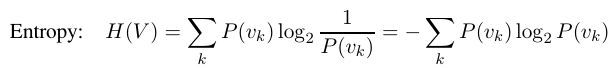

**Exercise**: compute the entropy for the fair coin 

In [40]:
from math import log2
p=0.5
#your code here

1.0


An attribute A with d distinct values divides the training set E into subsets E1 , . . . , Ed .
Each subset Ek has pk positive examples and nk negative examples, so if we go along that
branch, we will need an additional B(pk /(pk + nk )) bits of information to answer the ques-
tion. A randomly chosen example from the training set has the kth value for the attribute with
probability (p k + nk )/(p + n), so the expected entropy remaining after testing attribute A is


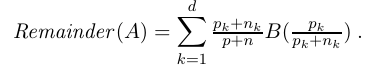

## Information gain 
Information gain from the attribute test on A is the expected reduction in entropy: 

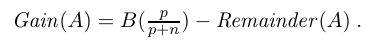

**Exercise** Compute the Gain for: Patrons and Type

In [10]:
attribute = "Type"
vs = data[attribute].unique() # get the unique value for the selected attribute

def B(p):
    """
    The entropy of the boolean variable that is true with probability p
    """
    
    if p==1.0:
        return 0
    elif p==0:
        return 0
    else:
        # your code here
        return None
        
p = len(data[data["WillWait"]=="Yes"])
n = len(data[data["WillWait"]=="No"])

print(f"p={p}, n={n}")

remainder = 0
for value in vs:
    
    pk = len(data[(data[attribute]==value) & (data["WillWait"]=="Yes")])
    nk = len(data[(data[attribute]==value) & (data["WillWait"]=="No")])
    print(f"value of attribute = {value}; pk={pk}, nk={nk}")
    ##your code here
    
#your code here
infogain 

p=6, n=6
value of attribute = French; pk=1, nk=1
value of attribute = Thai; pk=2, nk=2
value of attribute = Burger; pk=2, nk=2
value of attribute = Italian; pk=1, nk=1


Let's see a sample of our data: first 5 lines

In [7]:
data.head()

,Alt,Bar,Fri,Hyn,Pat,Price,Rain,Res,Type,Est,WillWait
0,Yes,No,No,Yes,Some,$$$,No,Yes,French,0–10,Yes
1,Yes,No,No,Yes,Full,$,No,No,Thai,30–60,No
2,No,Yes,No,No,Some,$,No,No,Burger,0–10,Yes
3,Yes,No,Yes,Yes,Full,$,Yes,No,Thai,10–30,Yes
4,Yes,No,Yes,No,Full,$$$,No,Yes,French,>60,No


Maybe we want to see the type of each column:

In [8]:
data.dtypes

Alt         object
Bar         object
Fri         object
Hyn         object
Pat         object
Price       object
Rain        object
Res         object
Type        object
Est         object
WillWait    object
dtype: object

In [9]:
data.columns

Index(['Alt', 'Bar', 'Fri', 'Hyn', 'Pat', 'Price', 'Rain', 'Res', 'Type',
       'Est', 'WillWait'],
      dtype='object')

## Train decision trees with scikit

Now, we want to assign numerical codes to the data at hand. The first option is to assign distinct numbers to each possible value in a column. LabelEncoder can do that. Let's try this for the Type column.

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
le.fit(data['Type'])
data_encoded = le.transform(data['Type'])

Let's see what we've got:

In [5]:
data['Type'],data_encoded

(0      French
 1        Thai
 2      Burger
 3        Thai
 4      French
 5     Italian
 6      Burger
 7        Thai
 8      Burger
 9     Italian
 10       Thai
 11     Burger
 Name: Type, dtype: object,
 array([1, 3, 0, 3, 1, 2, 0, 3, 0, 2, 3, 0]))

In [6]:
le.classes_

array(['Burger', 'French', 'Italian', 'Thai'], dtype=object)

Now, we should do this to every column in our data.

In [7]:
data_1 = data.apply(le.fit_transform)

And let's see what we've got:

In [8]:
data_1

,Alt,Bar,Fri,Hyn,Pat,Price,Rain,Res,Type,Est,WillWait
0,1,0,0,1,2,2,0,1,1,0,1
1,1,0,0,1,0,0,0,0,3,2,0
2,0,1,0,0,2,0,0,0,0,0,1
3,1,0,1,1,0,0,1,0,3,1,1
4,1,0,1,0,0,2,0,1,1,3,0
5,0,1,0,1,2,1,1,1,2,0,1
6,0,1,0,0,1,0,1,0,0,0,0
7,0,0,0,1,2,1,1,1,3,0,1
8,0,1,1,0,0,0,1,0,0,3,0
9,1,1,1,1,0,2,0,1,2,1,0


Let's build the classifier (model) in form of a decision tree. The criterion for attribute selection will be set to Information Gain, hence we specify "entropy" as its value. 

In [9]:
from sklearn import tree
#clf = tree.DecisionTreeClassifier(criterion="entropy")
clf = tree.DecisionTreeClassifier(criterion="entropy")

First, we grab the values of all attributes: based upon them, we will predict the value of the target (the label).

In [10]:
x = data_1[data.columns.drop('WillWait')]

What do we have in the attribute part of our data?

In [11]:
x

,Alt,Bar,Fri,Hyn,Pat,Price,Rain,Res,Type,Est
0,1,0,0,1,2,2,0,1,1,0
1,1,0,0,1,0,0,0,0,3,2
2,0,1,0,0,2,0,0,0,0,0
3,1,0,1,1,0,0,1,0,3,1
4,1,0,1,0,0,2,0,1,1,3
5,0,1,0,1,2,1,1,1,2,0
6,0,1,0,0,1,0,1,0,0,0
7,0,0,0,1,2,1,1,1,3,0
8,0,1,1,0,0,0,1,0,0,3
9,1,1,1,1,0,2,0,1,2,1


In [12]:
x.iloc[1]

Alt      1
Bar      0
Fri      0
Hyn      1
Pat      0
Price    0
Rain     0
Res      0
Type     3
Est      2
Name: 1, dtype: int64

Then, we select the array containing the labels (the values we want to predict for each example).

In [13]:
y = data_1['WillWait']

Which are the labels corresponding to each example?

In [14]:
y

0     1
1     0
2     1
3     1
4     0
5     1
6     0
7     1
8     0
9     0
10    0
11    1
Name: WillWait, dtype: int64

An now we generate the model.

In [15]:
clf.fit(x,y)

DecisionTreeClassifier(criterion='entropy')

In [16]:
from sklearn.tree import export_text
r = export_text(clf, feature_names = list(x.columns))
print(r)

|--- Pat <= 1.50
|   |--- Hyn <= 0.50
|   |   |--- class: 0
|   |--- Hyn >  0.50
|   |   |--- Rain <= 0.50
|   |   |   |--- Type <= 1.00
|   |   |   |   |--- class: 1
|   |   |   |--- Type >  1.00
|   |   |   |   |--- class: 0
|   |   |--- Rain >  0.50
|   |   |   |--- class: 1
|--- Pat >  1.50
|   |--- class: 1



As an alternative to the textual representation, you can save the treee as a pdf file (graphviz needs to be installed).

In [17]:
import graphviz
#dot_data = tree.export_graphviz(clf, out_file = None, feature_names= data_1.columns.get_values())
dot_data = tree.export_graphviz(clf, out_file = None, feature_names=x.columns)

graph = graphviz.Source(dot_data)
graphviz.Source(dot_data).view()
graph.render("restaurant")

'restaurant.pdf'

Note: If wand import error, this command might help: pip install Wand

Also check the file /etc/ImageMagick-6/policy.xml to see the reading rights. You have to see a line like this:

\< policy domain="coder" rights="read" pattern="PDF" >

### Another way to encode non numerical attributes.
Sometimes, you don't want to introduce an arbitrary order relationship between different values. For example, we have 0 < 1 < 2 < 3, but we have no reason to say that Burger < French < Italian < Thai, so LabeEncoder established  sort of hierarchy which does not exist in the original data. To address this, we can use get_dummies. The idea used here is that, if you have a column with k different values, this gets encoded as a set of k distinct columns, one for each value. A column generated this way can have only 0 and 1 as possible values. 

In [19]:
data_2 = pd.get_dummies(data, columns=data.columns)
data_2

,Alt_No,Alt_Yes,Bar_No,Bar_Yes,Fri_No,Fri_Yes,Hyn_No,Hyn_Yes,Pat_Full,Pat_None,...,Type_Burger,Type_French,Type_Italian,Type_Thai,Est_0–10,Est_10–30,Est_30–60,Est_>60,WillWait_No,WillWait_Yes
0,0,1,1,0,1,0,0,1,0,0,...,0,1,0,0,1,0,0,0,0,1
1,0,1,1,0,1,0,0,1,1,0,...,0,0,0,1,0,0,1,0,1,0
2,1,0,0,1,1,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,1
3,0,1,1,0,0,1,0,1,1,0,...,0,0,0,1,0,1,0,0,0,1
4,0,1,1,0,0,1,1,0,1,0,...,0,1,0,0,0,0,0,1,1,0
5,1,0,0,1,1,0,0,1,0,0,...,0,0,1,0,1,0,0,0,0,1
6,1,0,0,1,1,0,1,0,0,1,...,1,0,0,0,1,0,0,0,1,0
7,1,0,1,0,1,0,0,1,0,0,...,0,0,0,1,1,0,0,0,0,1
8,1,0,0,1,0,1,1,0,1,0,...,1,0,0,0,0,0,0,1,1,0
9,0,1,0,1,0,1,0,1,1,0,...,0,0,1,0,0,1,0,0,1,0


In [20]:
clf = tree.DecisionTreeClassifier(criterion="entropy")
x = data_2[data_2.columns.drop(['WillWait_No', 'WillWait_Yes'])]
y = data_2['WillWait_Yes']

In [21]:
x.head()

,Alt_No,Alt_Yes,Bar_No,Bar_Yes,Fri_No,Fri_Yes,Hyn_No,Hyn_Yes,Pat_Full,Pat_None,...,Res_No,Res_Yes,Type_Burger,Type_French,Type_Italian,Type_Thai,Est_0–10,Est_10–30,Est_30–60,Est_>60
0,0,1,1,0,1,0,0,1,0,0,...,0,1,0,1,0,0,1,0,0,0
1,0,1,1,0,1,0,0,1,1,0,...,1,0,0,0,0,1,0,0,1,0
2,1,0,0,1,1,0,1,0,0,0,...,1,0,1,0,0,0,1,0,0,0
3,0,1,1,0,0,1,0,1,1,0,...,1,0,0,0,0,1,0,1,0,0
4,0,1,1,0,0,1,1,0,1,0,...,0,1,0,1,0,0,0,0,0,1


In [22]:
clf.fit(x,y)
import graphviz
%matplotlib notebook
#dot_data = tree.export_graphviz(clf, out_file = None, feature_names=data_2.columns.get_values(),  
#                         filled=True)
dot_data = tree.export_graphviz(clf, out_file = None, feature_names=x.columns,  
                         filled=True)

graph = graphviz.Source(dot_data)
graph.view()
graph.render("restaurant2")

'restaurant2.pdf'

In [23]:
clf.predict(x.head())

array([1, 0, 1, 1, 0], dtype=uint8)

## How dowe evaluate a trained model?
The evaluation **needs to be done on a test set** which should be disjoint from the training set. For the moment, we will consider that we have y true and y pred.

In [28]:
y_true = [1,1, 0,0,0,1,1, 1]
y_pred = [1,1, 0,0,0,1,1, 0]

In classification, two very important metrics are precision and recall. The tp, tn, fp, fn can be seen in the confusion matrix. 

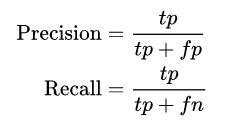

In [44]:
from sklearn.metrics import classification_report
print(classification_report(y_true,y_pred))

              precision    recall  f1-score   support

           0       0.43      1.00      0.60         3
           1       1.00      0.20      0.33         5

    accuracy                           0.50         8
   macro avg       0.71      0.60      0.47         8
weighted avg       0.79      0.50      0.43         8



In [45]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_true, y_pred)

array([[3, 0],
       [4, 1]])

**Exercise**
- what changes for y_pred = [1,1, 0,1,1,1,1, 1] - high recall for 1, but low precision
- what about y_pred = [1,0, 0,0,0,0,0, 0] - high precision, but low recall
Knowing only the acuracy does not tell the whole story: what kind of error do we have. Usually, increasing precision means decresing the recall (precision recall trade-off).